### Matplotlib Question on Datasets

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("C:\\Users\\lenovo\\Downloads\\matplotlib_sales_clean_1000 - matplotlib_sales_clean_1000.csv")

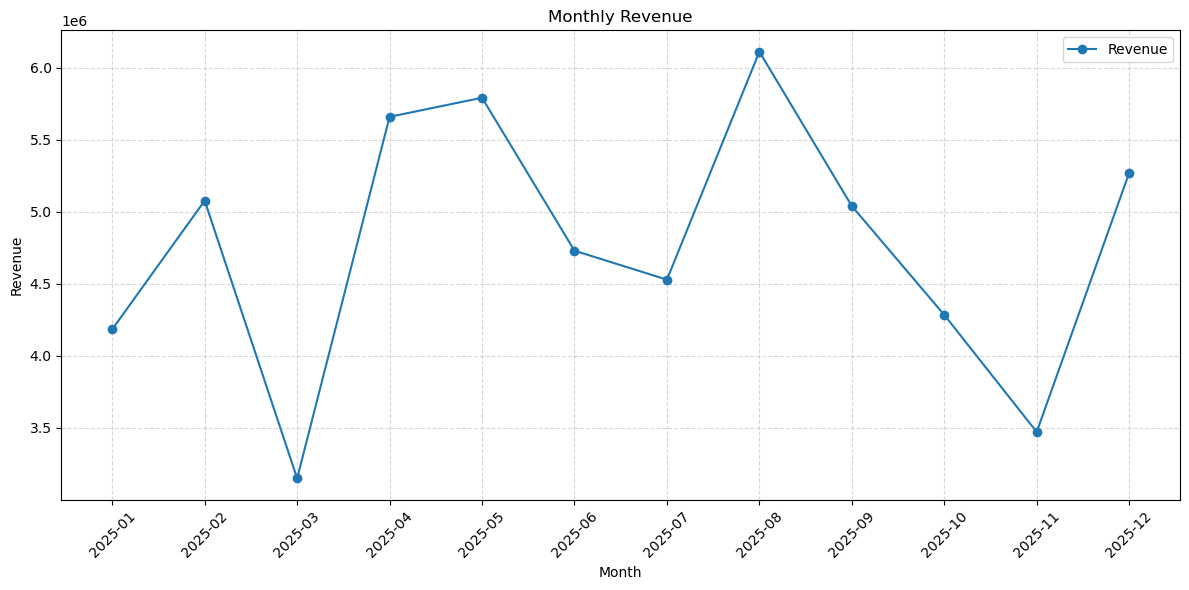

In [4]:
1.
# Create date and revenue column
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Revenue'] = pd.to_numeric(df['Revenue'])

# Group revenue by month
monthly_revenue = (
    df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum()
)

# plot the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o',
    label='Revenue'
)

# Add title and labels
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

# Add grid and legend 
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Rotate month labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

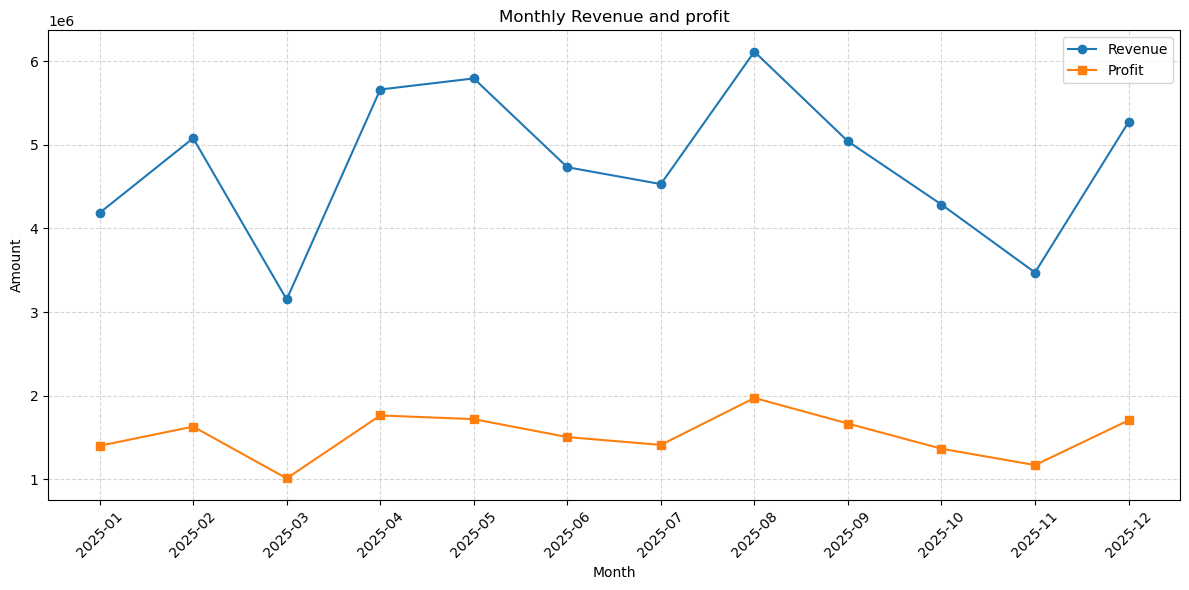

In [8]:
2.
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")

monthly_data = df.groupby(
    df["Order_Date"].dt.to_period("M")
)[["Revenue","Profit"]].sum()


plt.figure(figsize=(12, 6))

# Revenue
plt.plot(
    monthly_data.index.astype(str),
    monthly_data["Revenue"],
    marker="o",
    linestyle="-",
    label="Revenue"
)

# Profit 
plt.plot(
    monthly_data.index.astype(str),
    monthly_data["Profit"],
    marker="s",
    linestyle="-",
    label="Profit"
)

plt.title("Monthly Revenue and profit")
plt.xlabel("Month")
plt.ylabel("Amount")
 
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

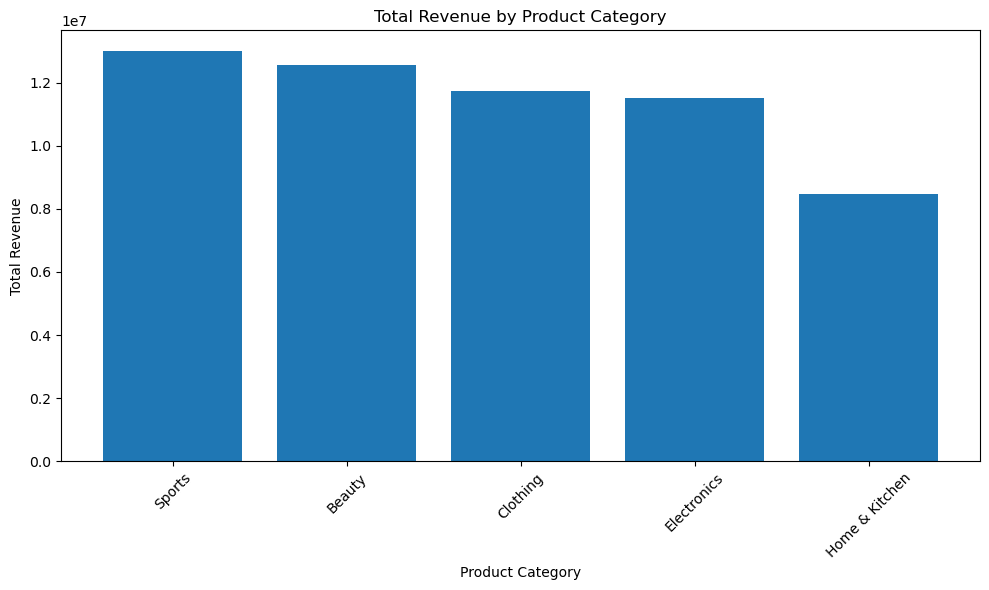

In [9]:
3.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")


# Calculate total Revenue by each Product_Category
category_revenue = (
    df.groupby("Product_Category")["Revenue"].sum()
    .sort_values(ascending=False)
)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values,
)

# Add title and labels 
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

# Rotate category labels if needed
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

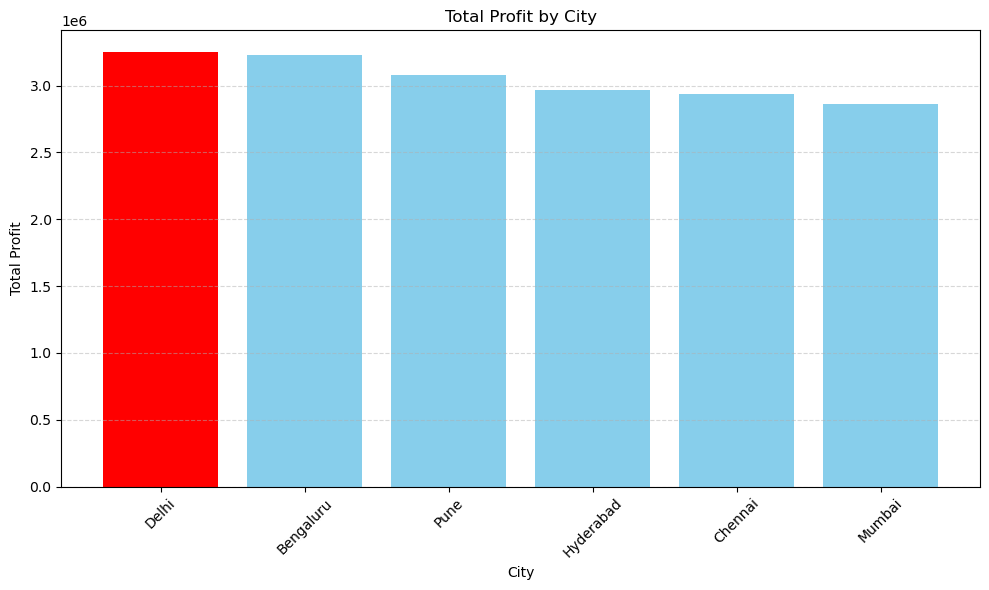

City with the higest profit: Delhi
highest_profit: 3251311.52


In [10]:
4.
# Make sure Profit is numeric 
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")

# Calculate total Profit by City
city_profit =(
    df.groupby("City")["Profit"].sum()
    .sort_values(ascending=False)
)

# Find the city with the highest profit
highest_city = city_profit.idxmax()

# Create colors: highlight highest-profit city
colors = [
    "red" if city == highest_city else 'skyblue'
    for city in city_profit.index
]

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    city_profit.index,
    city_profit.values,
    color=colors
)

plt.title("Total Profit by City")
plt.xlabel("City")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("City with the higest profit:",highest_city)
print("highest_profit:",city_profit[highest_city])

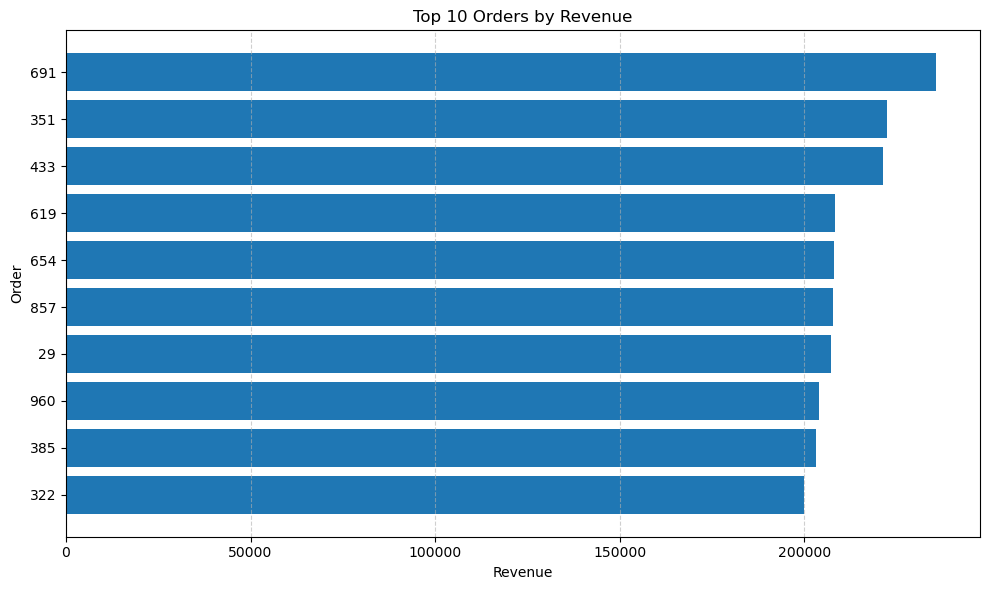

In [15]:
5.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Get the top 10 orders by Revenue
top_10 = df.nlargest(10, "Revenue").sort_values("Revenue")

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10.index.astype(str),
    top_10["Revenue"]
)

plt.title("Top 10 Orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

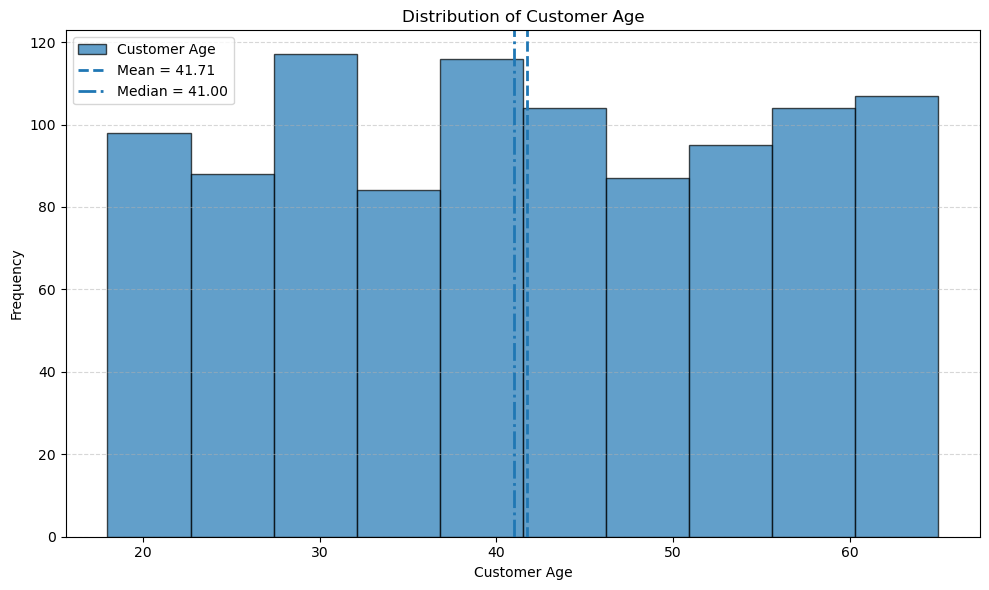

In [16]:
6.
df["Customer_Age"] = pd.to_numeric(df["Customer_Age"],errors="coerce")

# Remove missing values 
age = df["Customer_Age"].dropna()

# Calculate mean and median
mean_age = age.mean()
median_age = age.median()

# Create histogram with 10 bins
plt.figure(figsize=(10, 6))

plt.hist(
    age,
    bins=10,
    edgecolor="black",
    alpha=0.7,
    label="Customer Age"
)

# Add mean and median line
plt.axvline(
    mean_age,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_age:.2f}"
)

plt.axvline(
    median_age,
    linestyle="-.",
    linewidth=2,
    label=f"Median = {median_age:.2f}"
)

# Add title and labels
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")

# Add grid and legend 
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

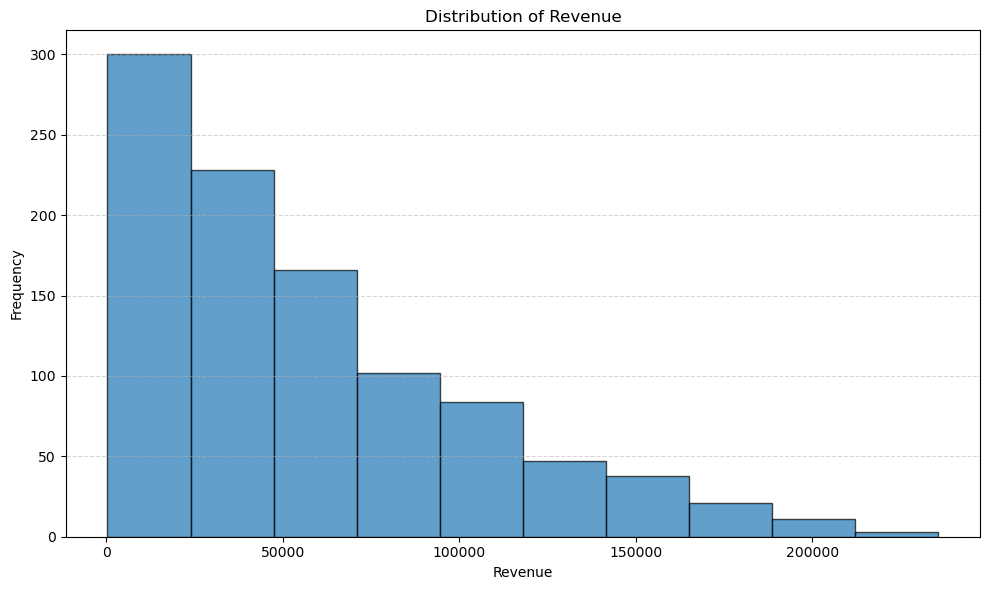

In [18]:
7.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Remove missing values
revenue = df["Revenue"].dropna()

# Create histogram 
plt.figure(figsize=(10, 6))

plt.hist(
    revenue,
    bins=10,
    edgecolor="black",
    alpha=0.7
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

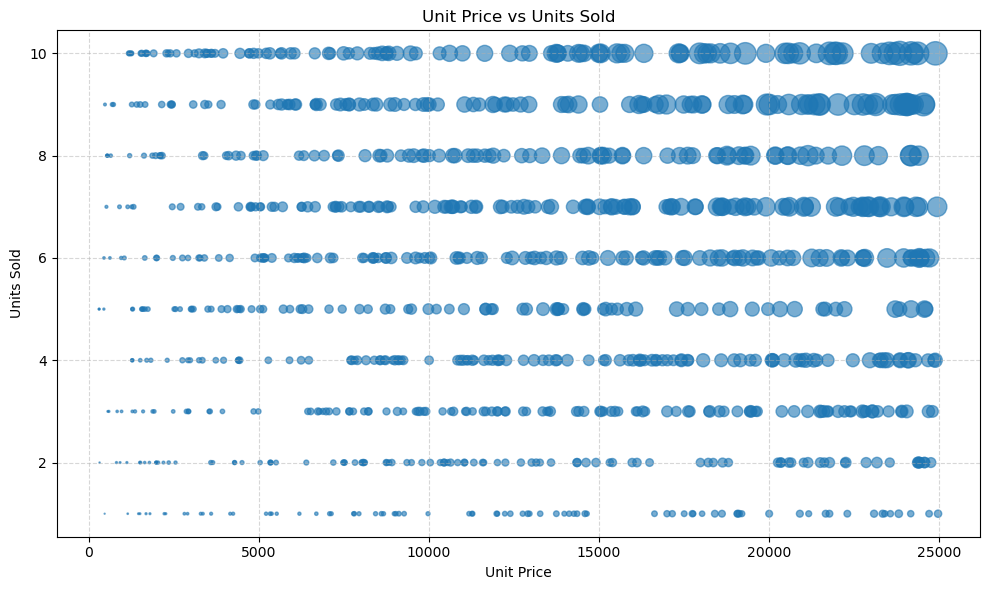

In [20]:
8.
df["Unit_Price"] = pd.to_numeric(df["Unit_Price"],errors="coerce")
df["Units_Sold"] = pd.to_numeric(df["Units_Sold"],errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Remove missing values
df= df.dropna(subset=["Unit_Price","Units_Sold","Revenue"])

# scale Revenue to create reasonable marker sizes
marker_sizes = (df["Revenue"]/df["Revenue"].max())*300

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Unit_Price"],
    df["Units_Sold"],
    s=marker_sizes,
    alpha=0.6
)

plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

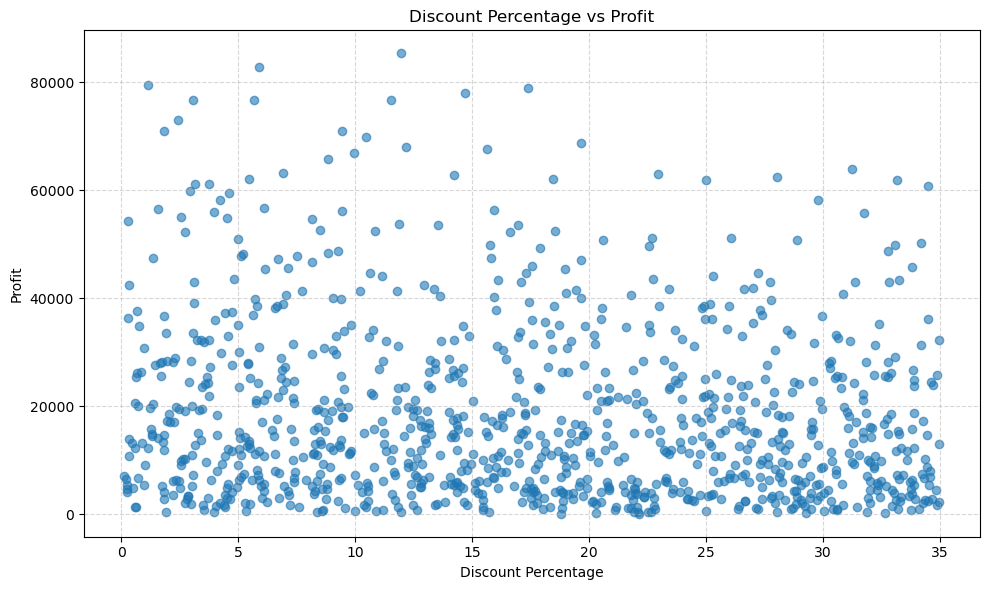

In [21]:
9.
df["Discount_Pct"] = pd.to_numeric(df["Discount_Pct"],errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")

# Remove missing values
data = df.dropna(subset=["Discount_Pct","Profit"])

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    data["Discount_Pct"],
    data["Profit"],
    alpha=0.6
)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

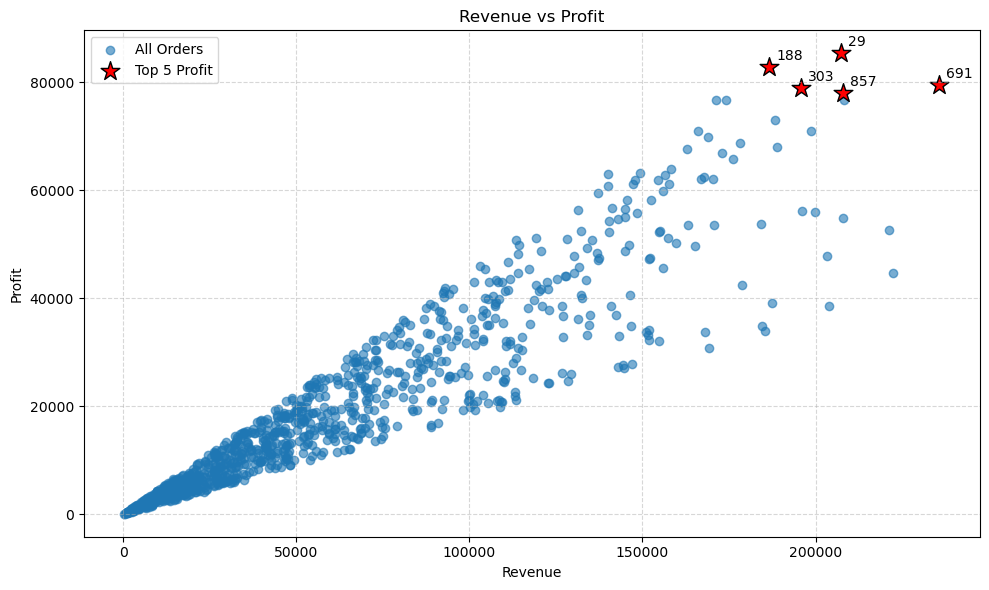

In [22]:
10.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")

# Remove missing values
data = df.dropna(subset=["Revenue","Profit"])

# select the 5 orders with the highest Profit
top_5 = data.nlargest(5, "Profit")

# Create scatter plot
plt.figure(figsize=(10, 6))

# Plot all orders
plt.scatter(
    data["Revenue"],
    data["Profit"],
    alpha=0.6,
    label="All Orders"
)

# Highlight top 5 profit orders
plt.scatter(
    top_5["Revenue"],
    top_5["Profit"],
    color="red",
    marker="*",
    s=200,
    edgecolor="black",
    label="Top 5 Profit"
)

# Add labels for the top 5 orders
for index, row in top_5.iterrows():
    plt.annotate(
        str(index),
        (row["Revenue"], row["Profit"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

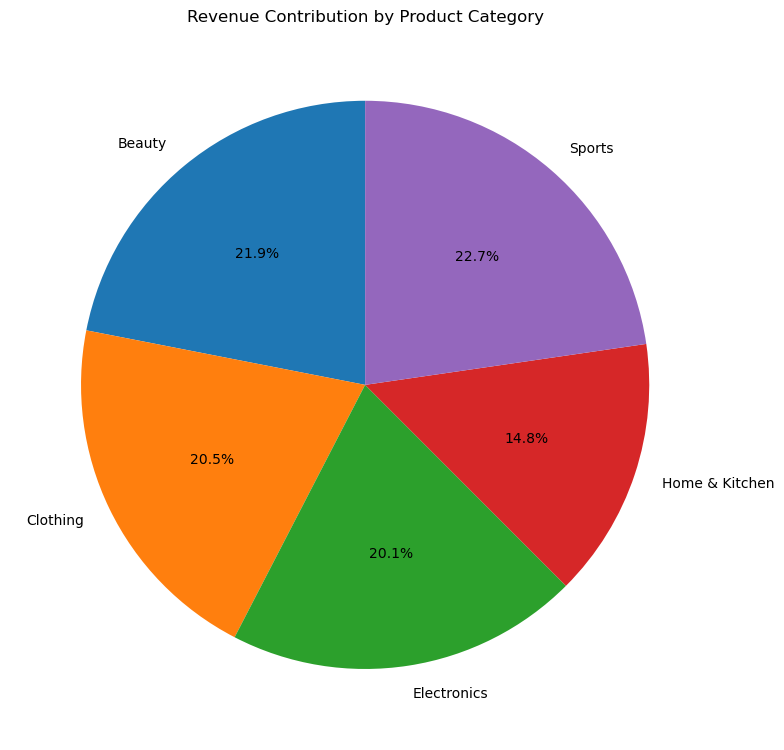

In [23]:
11.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Calculate total Revenue by Product_Category
category_revenue =(
    df.groupby("Product_Category")["Revenue"].sum()
)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Product Category")

plt.tight_layout()
plt.show()

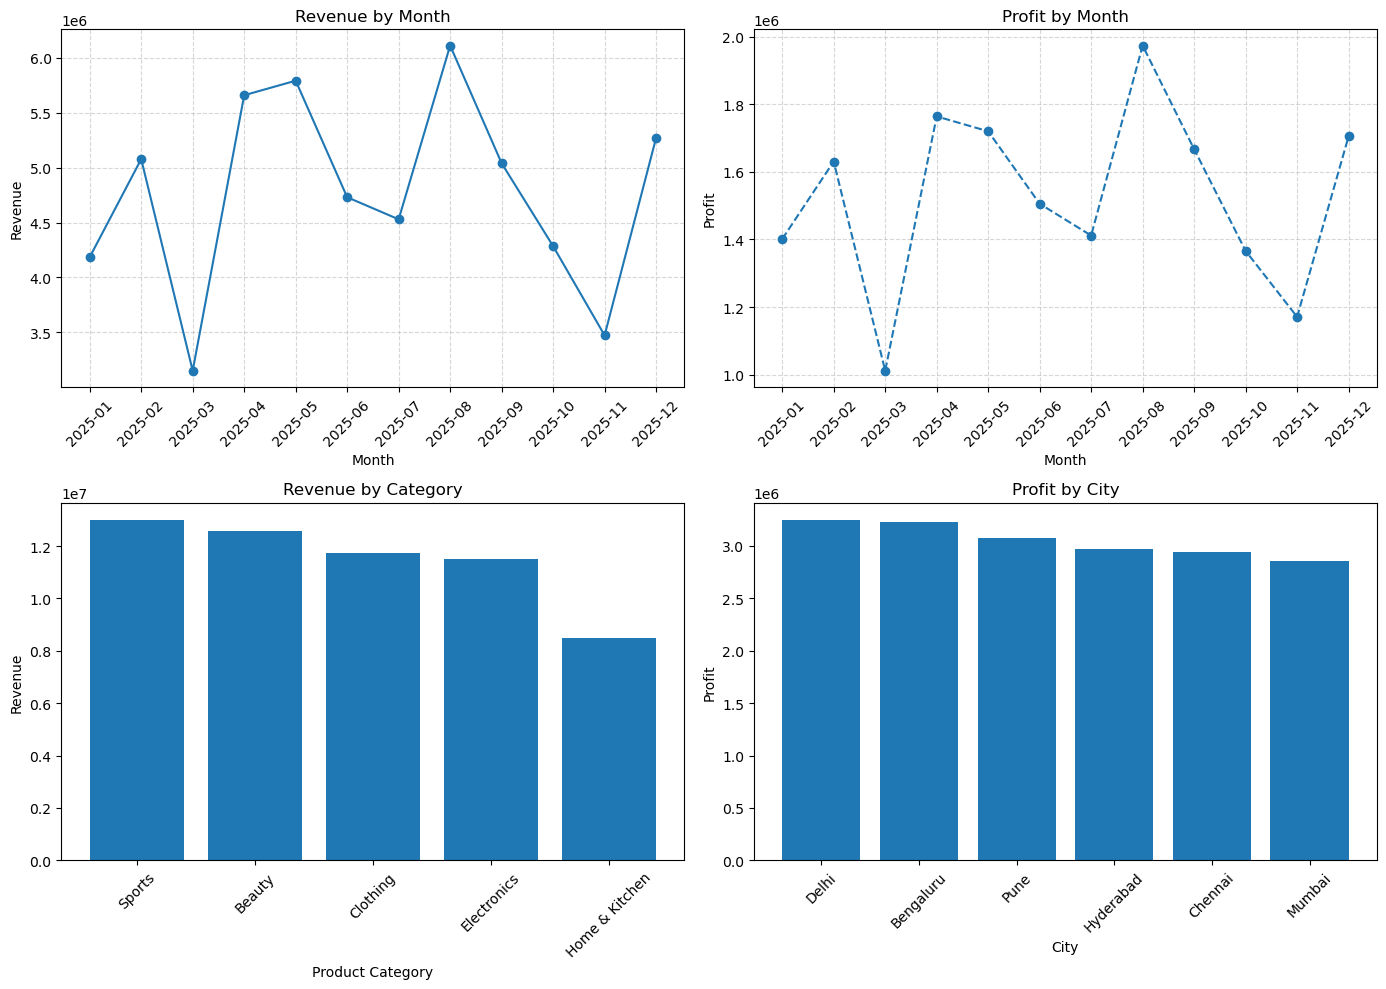

In [27]:
12.
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")

# ------------------------------------------------
# Prepare data
# ------------------------------------------------

# Revenue by Month
monthly_revenue=(
    df.groupby(df["Order_Date"].dt.to_period("M"))["Revenue"]
        .sum()
)

# Profit by month
monthly_profit=(
    df.groupby(df["Order_Date"].dt.to_period("M"))["Profit"]
        .sum()
)

# Revenue by category
category_revenue=(
    df.groupby("Product_Category")["Revenue"]
        .sum()
        .sort_values(ascending=False)
)

# Profit by city
city_profit =(
    df.groupby("City")["Profit"]
        .sum()
        .sort_values(ascending=False)
)


# ------------------------------------------------
# Create 2 x 2 subplot
# ------------------------------------------------

fig,axes = plt.subplots(2,2,figsize=(14,10))

# 1. Revenue by month
axes[0, 0].plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

axes[0, 0].set_title("Revenue by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True, linestyle="--", alpha=0.5)


# 2. Profit by Month
axes[0, 1].plot(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    marker="o",
    linestyle="--"
)

axes[0, 1].set_title("Profit by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True, linestyle="--", alpha=0.5)


# 3. Revenue by Category
axes[1, 0].bar(
    category_revenue.index,
    category_revenue.values
)

axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)


# 4. Profit by City
axes[1, 1].bar(
    city_profit.index,
    city_profit.values
)

axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)

# Adjust spacing
plt.tight_layout()

# Display the complete 2 x 2 figure
plt.show()

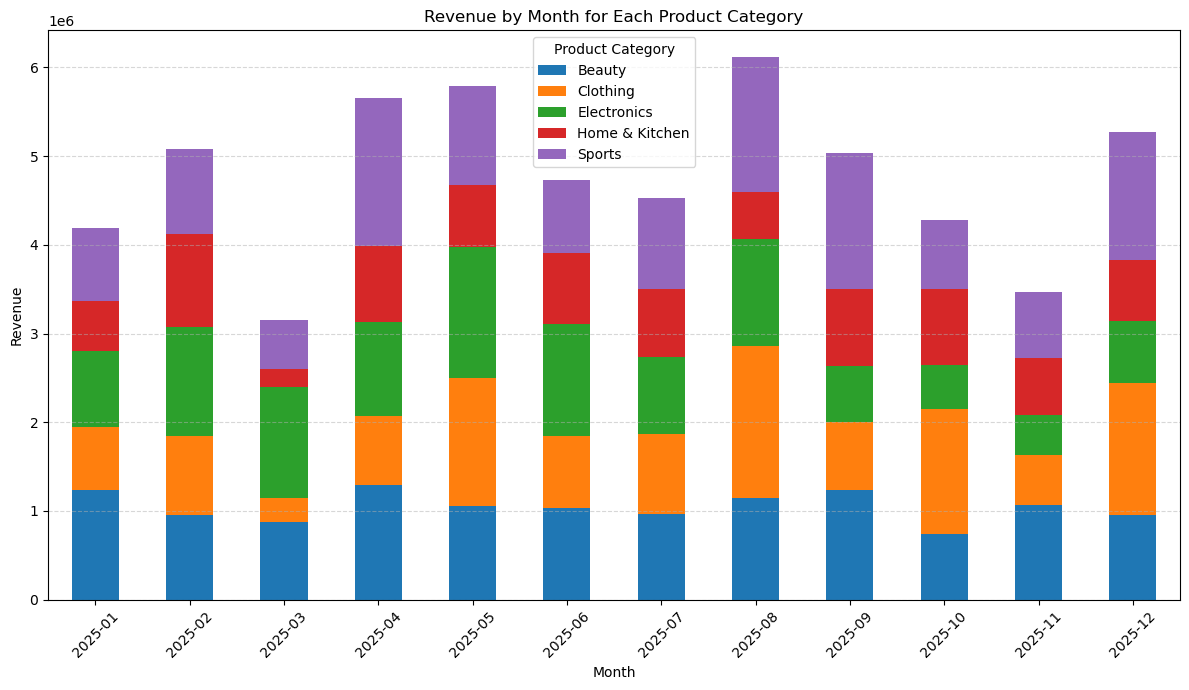

In [28]:
13.
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Group Revenue by Month and Product_Category
monthly_category = (
    df.groupby([
        df["Order_Date"].dt.to_period("M"),
        "Product_Category"
    ])["Revenue"]
    .sum()
    .unstack(fill_value=0)
)

# Create stacked bar chart
monthly_category.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Revenue by Month for Each Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Product Category")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

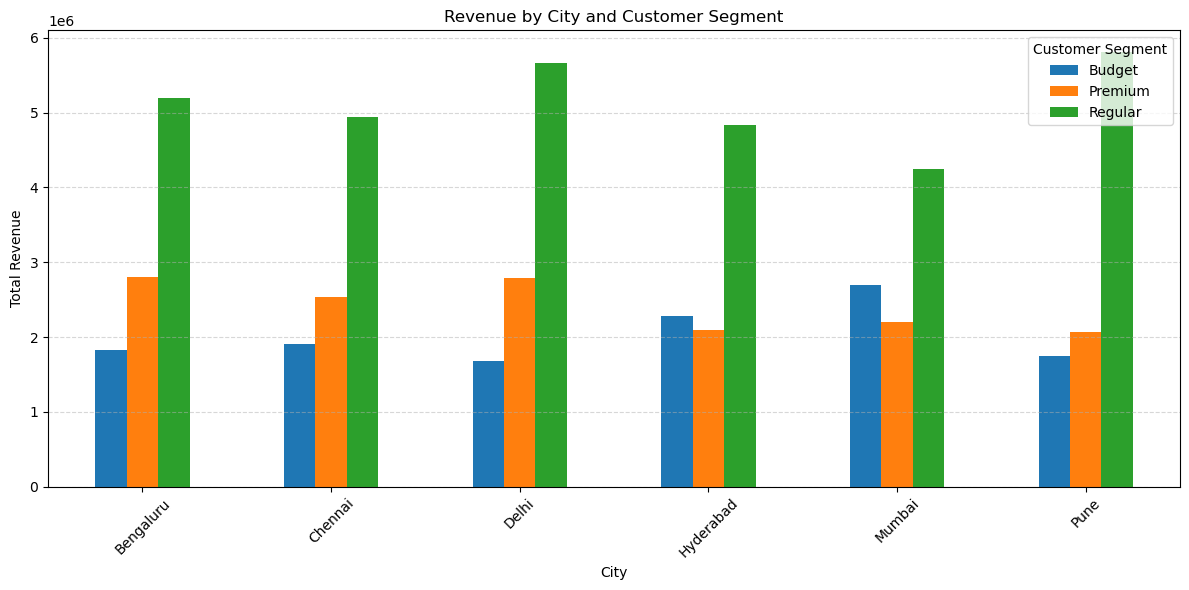

In [29]:
14.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Revenue by City and Customer Segment
city_segment = (
    df.groupby(["City", "Customer_Segment"])["Revenue"]
    .sum()
    .unstack(fill_value=0)
)

# Create bar chart
city_segment.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue by City and Customer Segment")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(title="Customer Segment")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

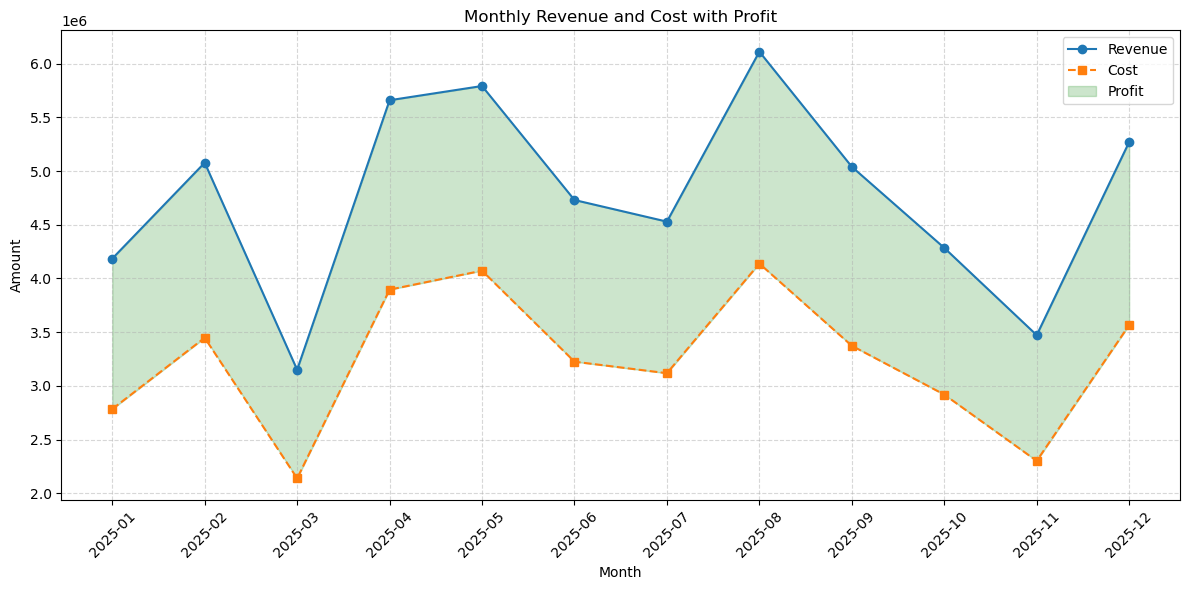

In [32]:
15.
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")
df["Cost"] = pd.to_numeric(df["Cost"], errors="coerce")

# Group by Month
monthly = (
    df.groupby(df["Order_Date"].dt.to_period("M"))[["Revenue", "Cost"]]
    .sum()
)

months = monthly.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly["Revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    months,
    monthly["Cost"],
    marker="s",
    linestyle="--",
    label="Cost"
)

# Shade the area between Revenue and Cost
plt.fill_between(
    range(len(months)),
    monthly["Cost"].values,
    monthly["Revenue"].values,
    alpha=0.2,
    color="green",
    label="Profit"
)

plt.title("Monthly Revenue and Cost with Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

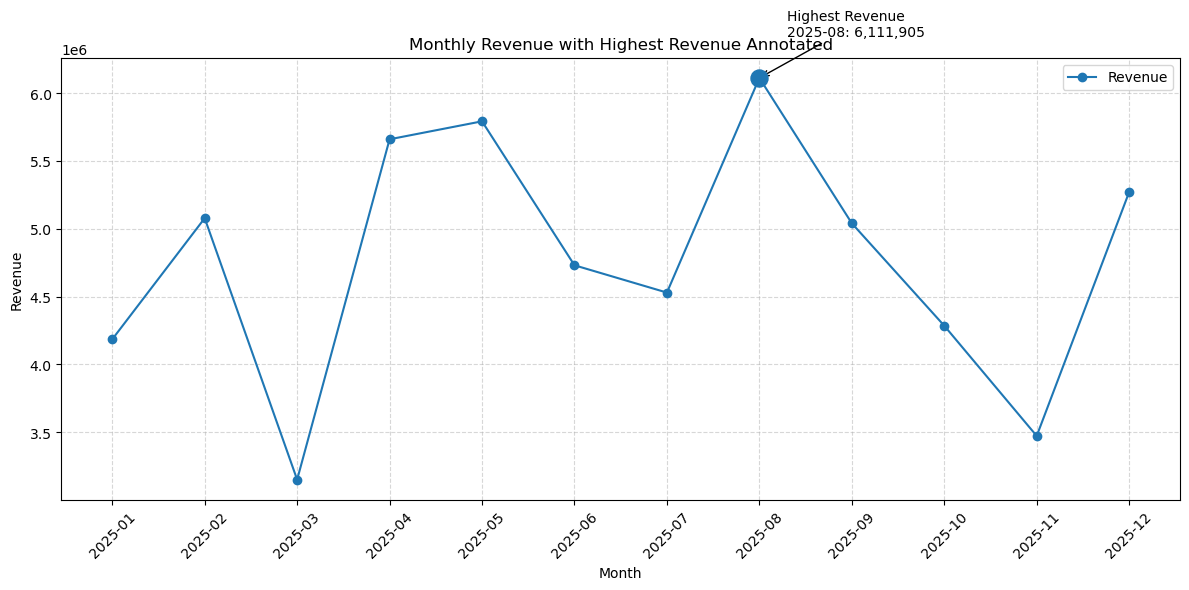

Highest Revenue Month: 2025-08
Highest Revenue: 6111904.58


In [34]:
16.
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

# Calculate monthly Revenue
monthly_revenue=(
    df.groupby(df["Order_Date"].dt.to_period("M"))["Revenue"]
      .sum()
)

# Find highest Revenue Month
highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

months = monthly_revenue.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_revenue.values,
    marker="o",
    label="Revenue"
)

# Position of highest point
highest_position = list(monthly_revenue.index).index(highest_month)

# Highlight the highest point
plt.scatter(
    highest_position,
    highest_revenue,
    s=150,
    zorder=5
)

# Annotate the point
plt.annotate(
    f"Highest Revenue\n{highest_month}: {highest_revenue:,.0f}",
    xy=(str(highest_month), highest_revenue),
    xytext=(20, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Revenue with Highest Revenue Annotated")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

print("Highest Revenue Month:", highest_month)
print("Highest Revenue:", highest_revenue)

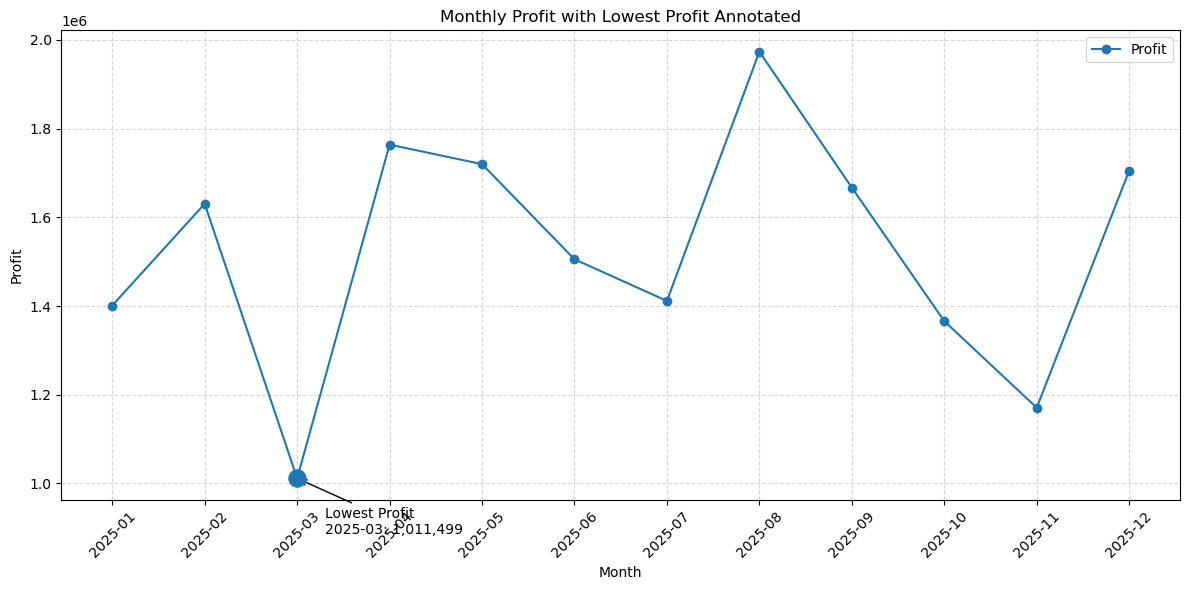

In [35]:
17.
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")

monthly_profit = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Profit"]
      .sum()
)

months = monthly_profit.index.astype(str)

lowest_month = monthly_profit.idxmin()
lowest_profit = monthly_profit.min()
lowest_position = list(monthly_profit.index).index(lowest_month)

plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_profit.values,
    marker="o",
    label="Profit"
)

plt.scatter(
    lowest_position,
    lowest_profit,
    s=150,
    zorder=5
)

plt.annotate(
    f"Lowest Profit\n{lowest_month}: {lowest_profit:,.0f}",
    xy=(lowest_position, lowest_profit),
    xytext=(20, -40),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Profit with Lowest Profit Annotated")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

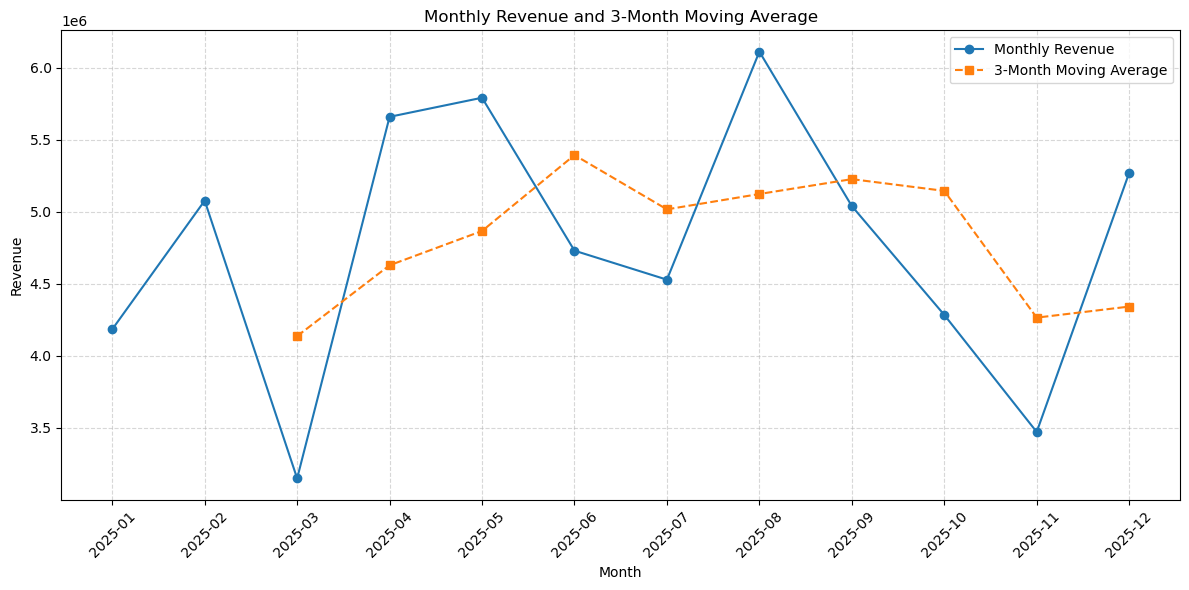

In [36]:
18.
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

monthly_revenue=(
    df.groupby(df["Order_Date"].dt.to_period("M"))["Revenue"]
      .sum()
)

# Calculate 3-month moving average
moving_average = monthly_revenue.rolling(window=3).mean()

months = monthly_revenue.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_revenue.values,
    marker="o",
    label="Monthly Revenue"
)

plt.plot(
    months,
    moving_average.values,
    marker="s",
    linestyle="--",
    label="3-Month Moving Average"
)

plt.title("Monthly Revenue and 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

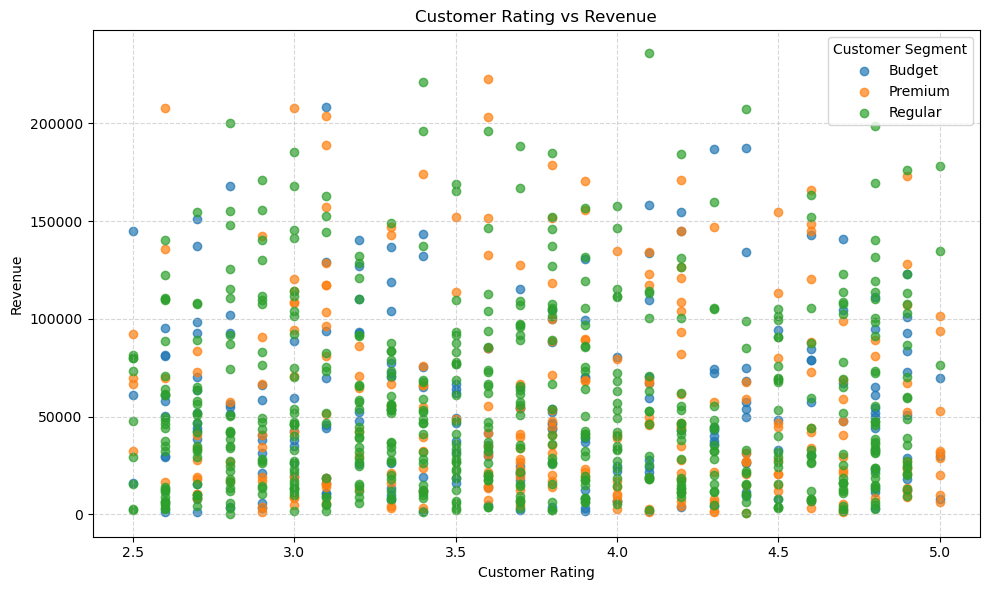

In [37]:
19.
df["Customer_Rating"] = pd.to_numeric(
    df["Customer_Rating"],
    errors="coerce"
)

df["Revenue"] = pd.to_numeric(
    df["Revenue"],
    errors="coerce"
)

data = df.dropna(
    subset=["Customer_Rating", "Revenue", "Customer_Segment"]
)

plt.figure(figsize=(10, 6))

for segment in data["Customer_Segment"].unique():
    segment_data = data[data["Customer_Segment"] == segment]

    plt.scatter(
        segment_data["Customer_Rating"],
        segment_data["Revenue"],
        alpha=0.7,
        label=segment
    )

plt.title("Customer Rating vs Revenue")
plt.xlabel("Customer Rating")
plt.ylabel("Revenue")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Customer Segment")

plt.tight_layout()
plt.show()

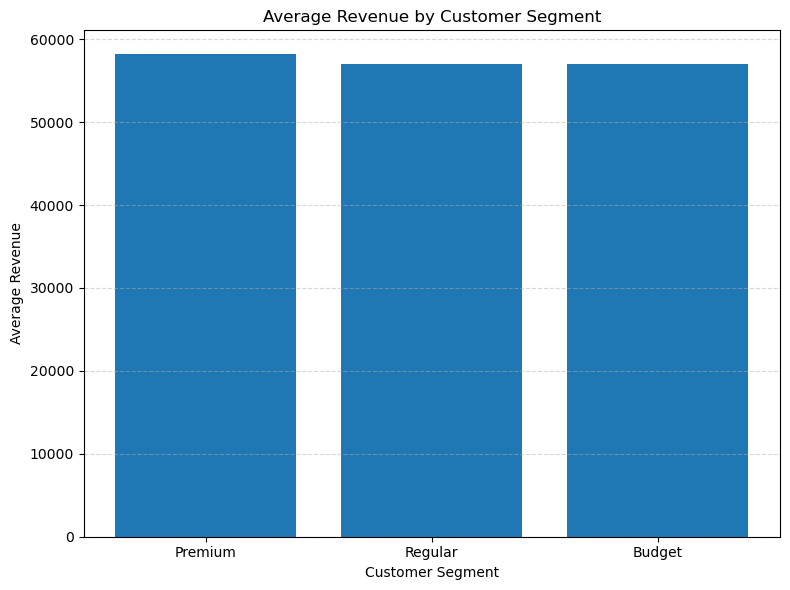

In [38]:
20.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

segments = ["Premium","Regular","Budget"]

average_revenue = (
    df.groupby("Customer_Segment")["Revenue"]
      .mean()
      .reindex(segments)
)


plt.figure(figsize=(8, 6))

plt.bar(
    average_revenue.index,
    average_revenue.values,
)

plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")

plt.grid(axis="y",linestyle="--",alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12460\3254861801.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


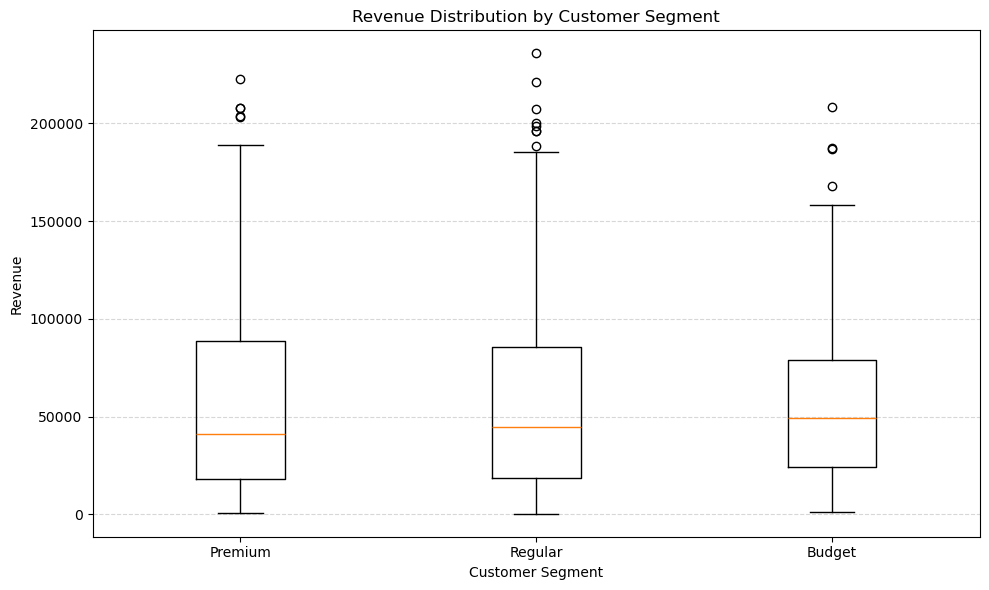

In [41]:
21.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

segments = ["Premium", "Regular", "Budget"]

# Remove missing values
data = [
    df.loc[
        df["Customer_Segment"] == segment,
        "Revenue"
    ].dropna()
    for segment in segments
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data,
    labels=segments
)

plt.title("Revenue Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.grid(axis="y",linestyle="--",alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12460\1488911793.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


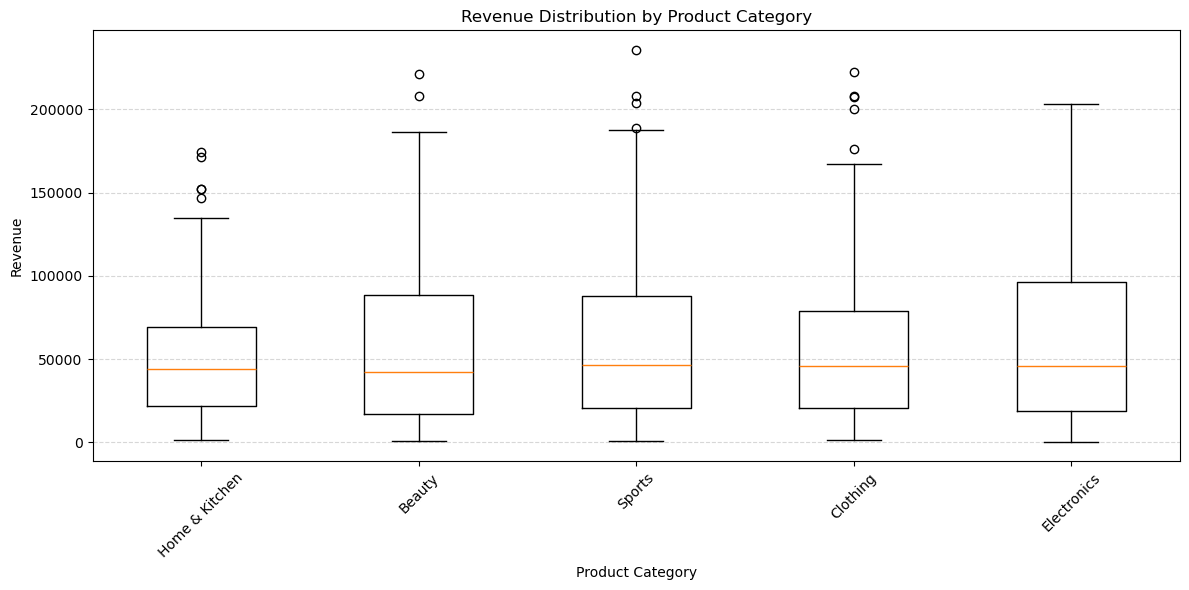

In [43]:
22.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

Categories = df["Product_Category"].dropna().unique()

data = [
    df.loc[
        df["Product_Category"] == category,
        "Revenue"
    ].dropna()
    for category in Categories
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    labels=Categories
)

plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y",linestyle="--",alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12460\2754086352.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend()


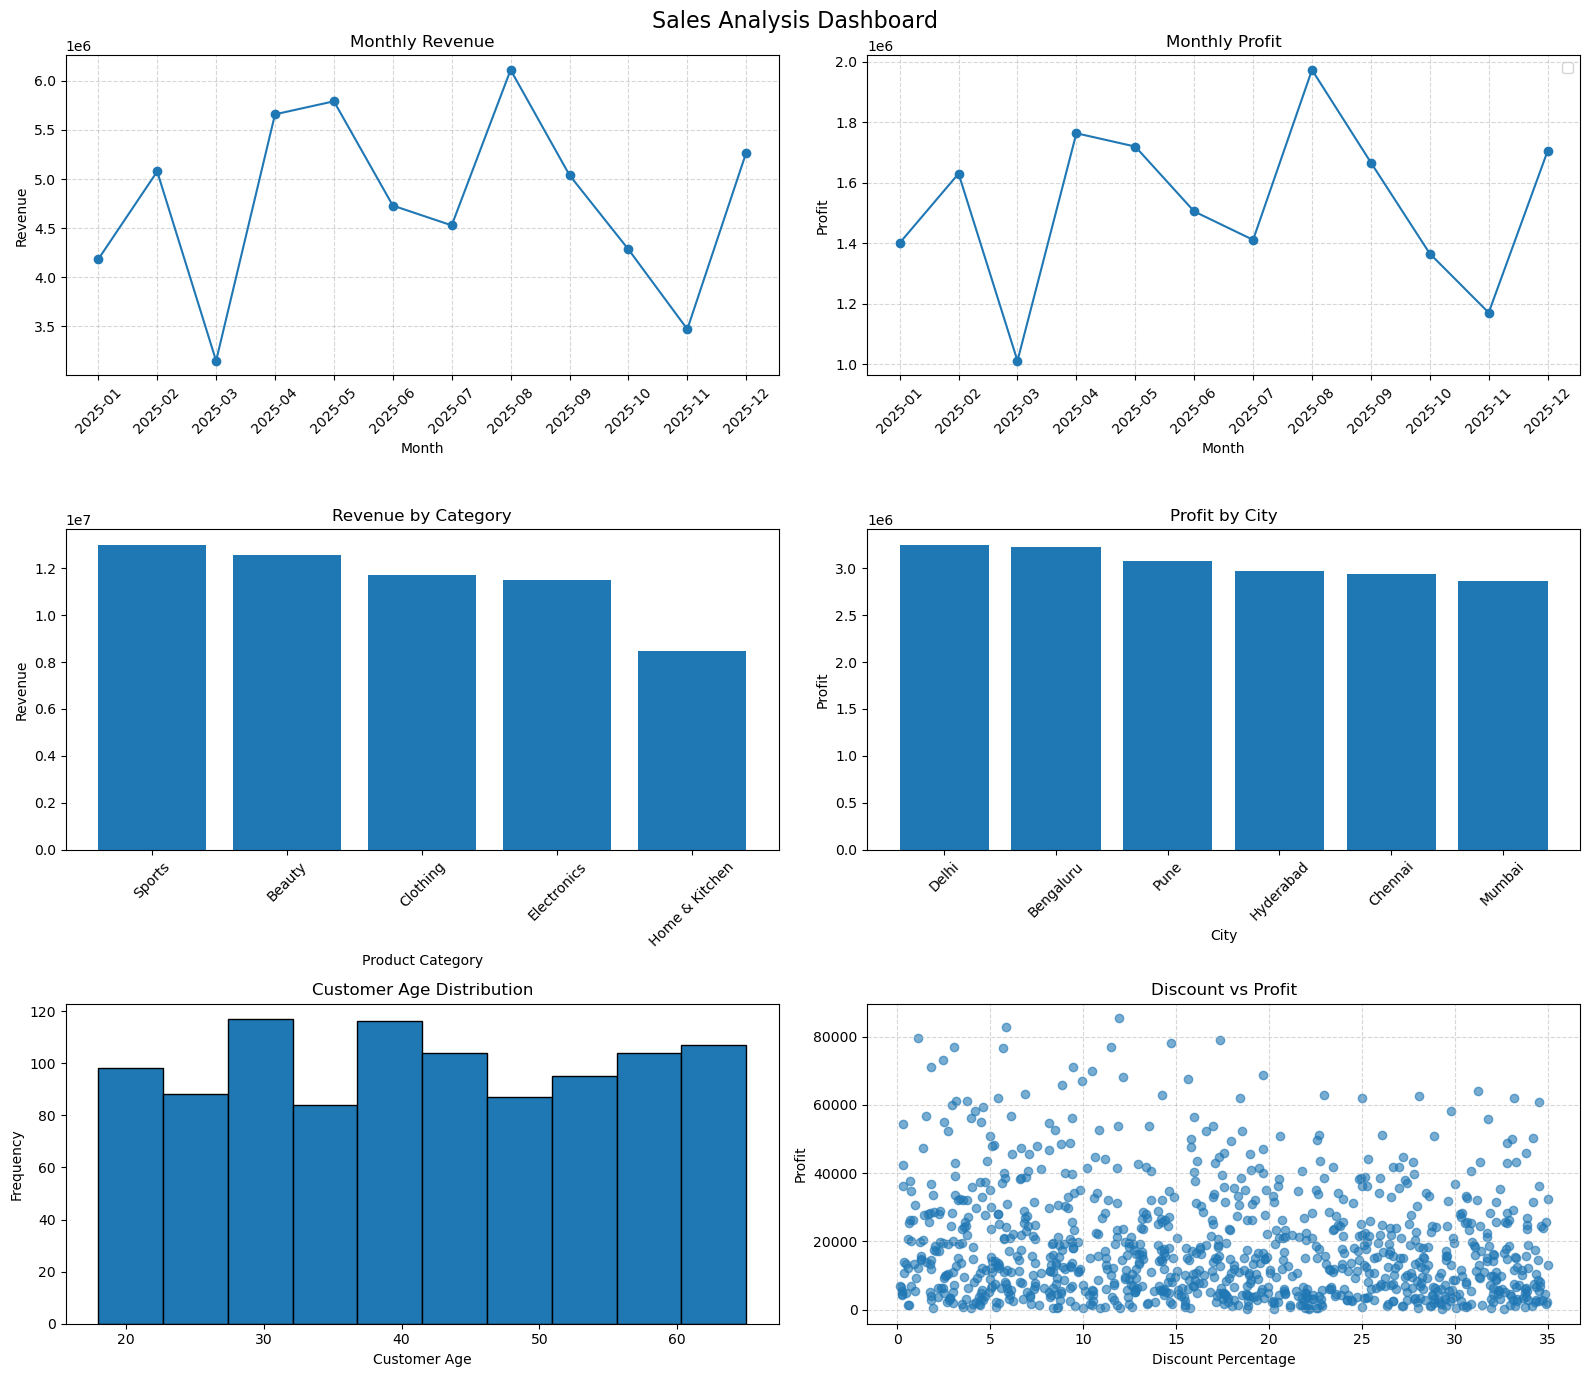

In [47]:
23.
# Convert Columns

df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")
df["Customer_Age"] = pd.to_numeric(df["Customer_Age"],errors="coerce")
df["Discount_Pct"] = pd.to_numeric(df["Discount_Pct"],errors="coerce")

# Prepare grouped data 
monthly_revenue = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_profit = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Profit"].sum()

category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

# Create 3 × 2 dashboard

fig, axes = plt.subplots(3, 2,figsize=(16, 14))

# 1. Monthly Revenue
axes[0, 0].plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True,linestyle="--",alpha=0.5)

# 2. Monthly Profit
axes[0, 1].plot(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    marker="o"
)

axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True,linestyle="--",alpha=0.5)
axes[0, 1].legend()

# 3. Category Revenue
axes[1, 0].bar(
    category_revenue.index,
    category_revenue.values
)

axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x",rotation=45)


# 4. City Profit
axes[1, 1].bar(
    city_profit.index,
    city_profit.values
)

axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x",rotation=45)

# 5. Customer Age Distribution
axes[2, 0].hist(
    df["Customer_Age"].dropna(),
    bins=10,
    edgecolor="black"
)

axes[2, 0].set_title("Customer Age Distribution")
axes[2, 0].set_xlabel("Customer Age")
axes[2, 0].set_ylabel("Frequency")

# 6. Discount vs Profit
axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)

axes[2, 1].set_title("Discount vs Profit")
axes[2, 1].set_xlabel("Discount Percentage")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True,linestyle="--",alpha=0.5)

fig.suptitle("Sales Analysis Dashboard",fontsize=16)
plt.tight_layout()
plt.show()

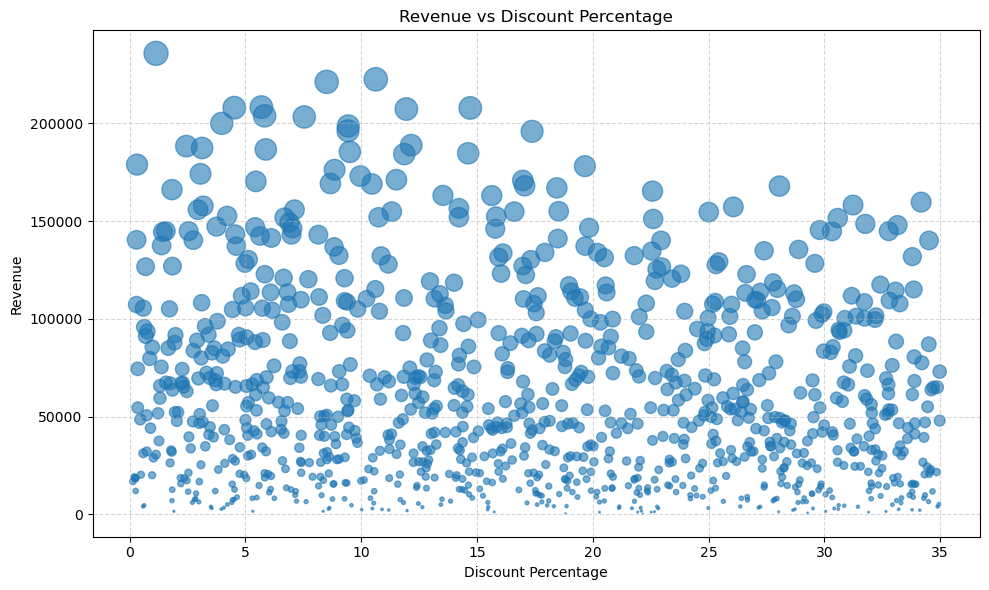

In [48]:
24.
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")
df["Discount_Pct"] = pd.to_numeric(df["Discount_Pct"], errors="coerce")
df["Units_Sold"] = pd.to_numeric(df["Units_Sold"], errors="coerce")

data = df.dropna(
    subset=["Revenue", "Discount_Pct", "Units_Sold"]
)

# Scale Units_Solid for marker sizes
marker_size = (
    data["Units_Sold"] / data["Units_Sold"].max()
) * 500 + 20

plt.figure(figsize=(10, 6))

plt.scatter(
    data["Discount_Pct"],
    data["Revenue"],
    s=marker_sizes,
    alpha=0.6
)

plt.title("Revenue vs Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Revenue")
plt.grid(True,linestyle="--",alpha=0.5)

plt.tight_layout()
plt.show()

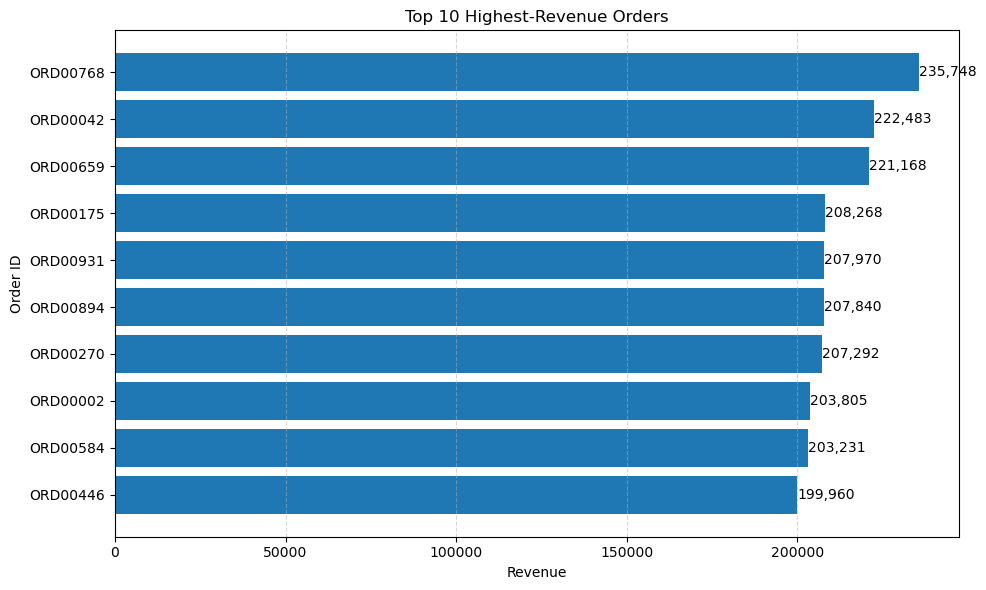

In [49]:
25.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Select top 10 highest-revenue orders 
top_10 = (
    df.nlargest(10, "Revenue")
        .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Order_ID"].astype(str),
    top_10["Revenue"]
)

plt.title("Top 10 Highest-Revenue Orders")
plt.xlabel("Revenue")
plt.ylabel("Order ID")
plt.grid(axis="x",linestyle="--",alpha=0.5)

# Display Revenue values beside the bar
for i,value in enumerate(top_10["Revenue"]):
    plt.text(
        value,
        i,
        f"{value:,.0f}",
        va="center"
    )
    
plt.tight_layout()
plt.show()

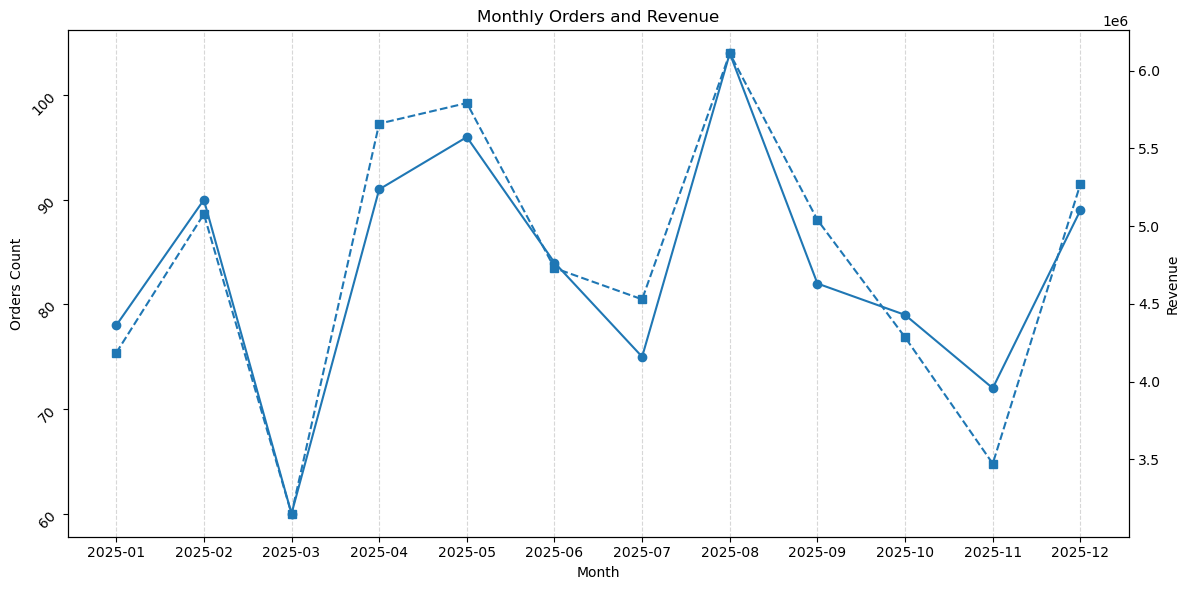

In [50]:
26.
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

monthly = df.groupby(
    df["Order_Date"].dt.to_period("M")
).agg(
    Orders=("Order_ID", "count"),
    Revenue=("Revenue", "sum")
)

months = monthly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6))

# First Y-axis: Order Count
ax1.plot(
    months,
    monthly["Orders"],
    marker="o",
    label="Orders"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Orders Count")
ax1.tick_params(axis="y",rotation=45)
ax1.grid(axis="x",linestyle="--",alpha=0.5)

# Second Y-axis: Revenue
ax2 = ax1.twinx()
ax2.plot(
    months,
    monthly["Revenue"],
    marker="s",
    linestyle="--",
    label="Revenue"
)

ax2.set_ylabel("Revenue")

plt.title("Monthly Orders and Revenue")

plt.tight_layout()
plt.show()

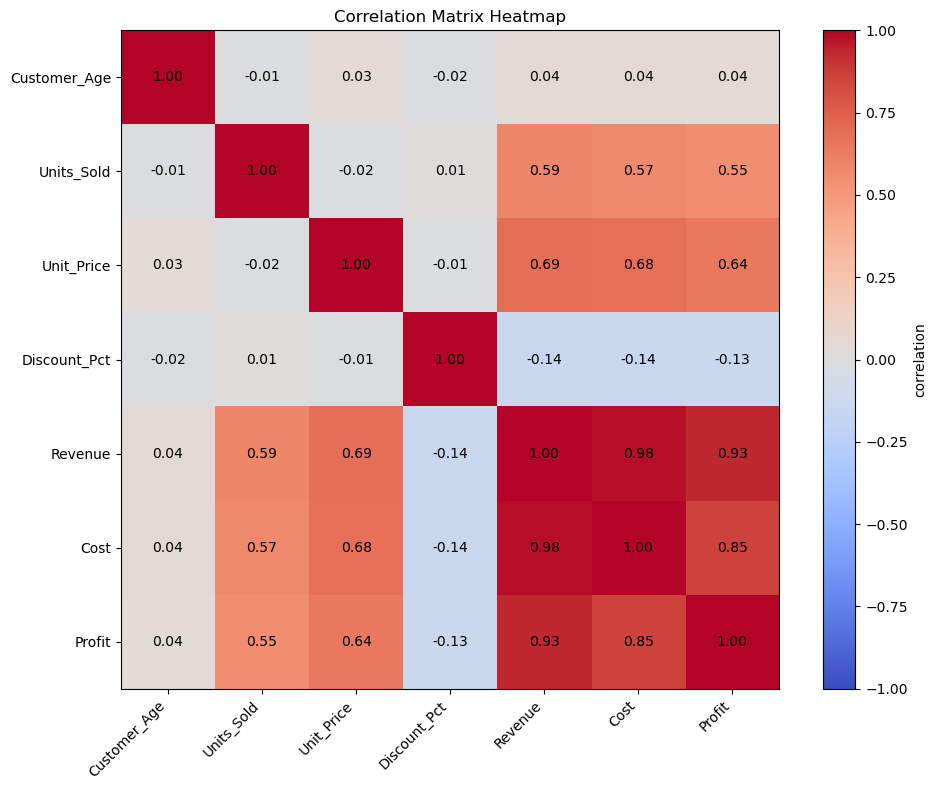

In [51]:
27.
columns = [
    "Customer_Age",
    "Units_Sold",
    "Unit_Price",
    "Discount_Pct",
    "Revenue",
    "Cost",
    "Profit"
]

# Convert columns to numeric
for col in columns:
    df[col] = pd.to_numeric(df[col],errors="coerce")

# Calculate correlation matrix
corr = df[columns].corr()

# Create heatmap using Matplotlib
fig,ax=plt.subplots(figsize=(10, 8))

image = ax.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Add labels
ax.set_xticks(range(len(columns)))
ax.set_yticks(range(len(columns)))
ax.set_xticklabels(columns,rotation=45,ha="right")
ax.set_yticklabels(columns)

# Display correlation values 
for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(image,ax=ax,label="correlation")


plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

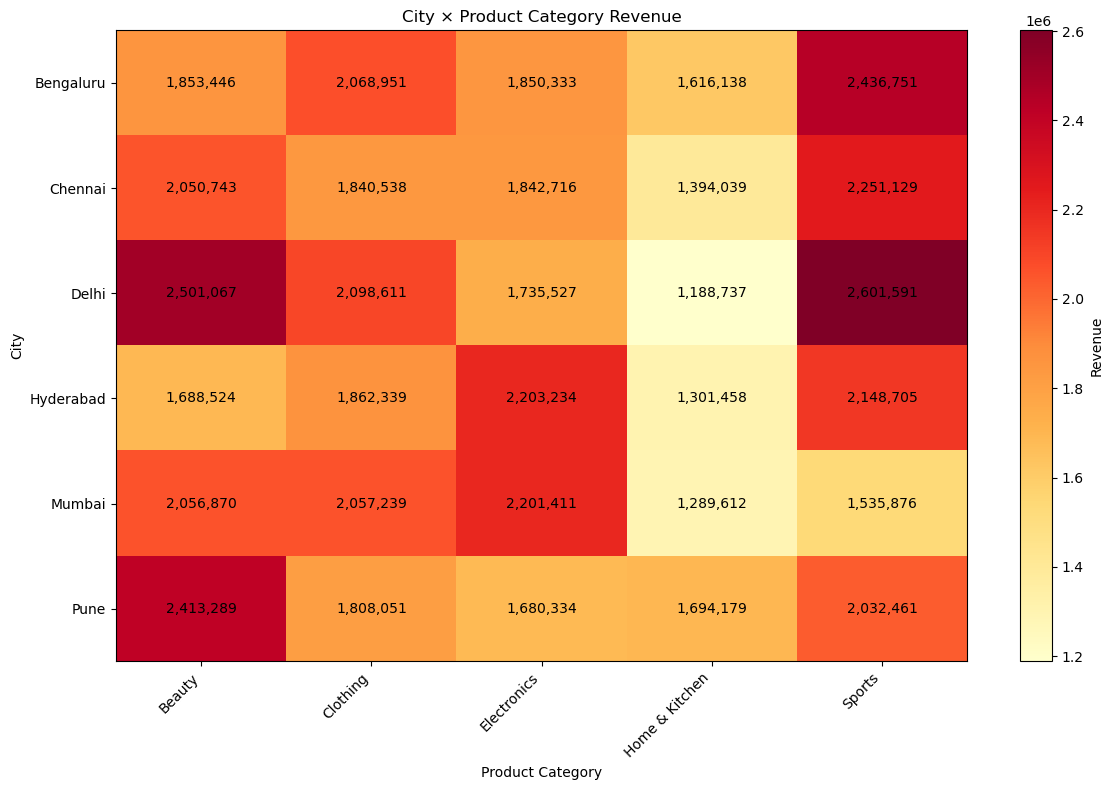

In [54]:
28.
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")

# Create City × Product_Category revenue table
city_category = (
    df.pivot_table(
        values="Revenue",
        index="City",
        columns="Product_Category",
        aggfunc="sum",
        fill_value=0
    )
)

fig, ax = plt.subplots(figsize=(12, 8))

image = ax.imshow(
    city_category.values,
    aspect="auto",
    cmap="YlOrRd"
)

ax.set_xticks(range(len(city_category.columns)))
ax.set_yticks(range(len(city_category.index)))

ax.set_xticklabels(
    city_category.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(city_category.index)

# Add Revenue values inside cell
for i in range(city_category.shape[0]):
    for j in range(city_category.shape[1]):
        ax.text(
            j,
            i,
            f"{city_category.iloc[i, j]:,.0f}",
            ha="center",
            va="center"
        )

plt.colorbar(image,ax=ax,label="Revenue")

plt.title("City × Product Category Revenue")
plt.xlabel("Product Category")
plt.ylabel("City")

plt.tight_layout()
plt.show()

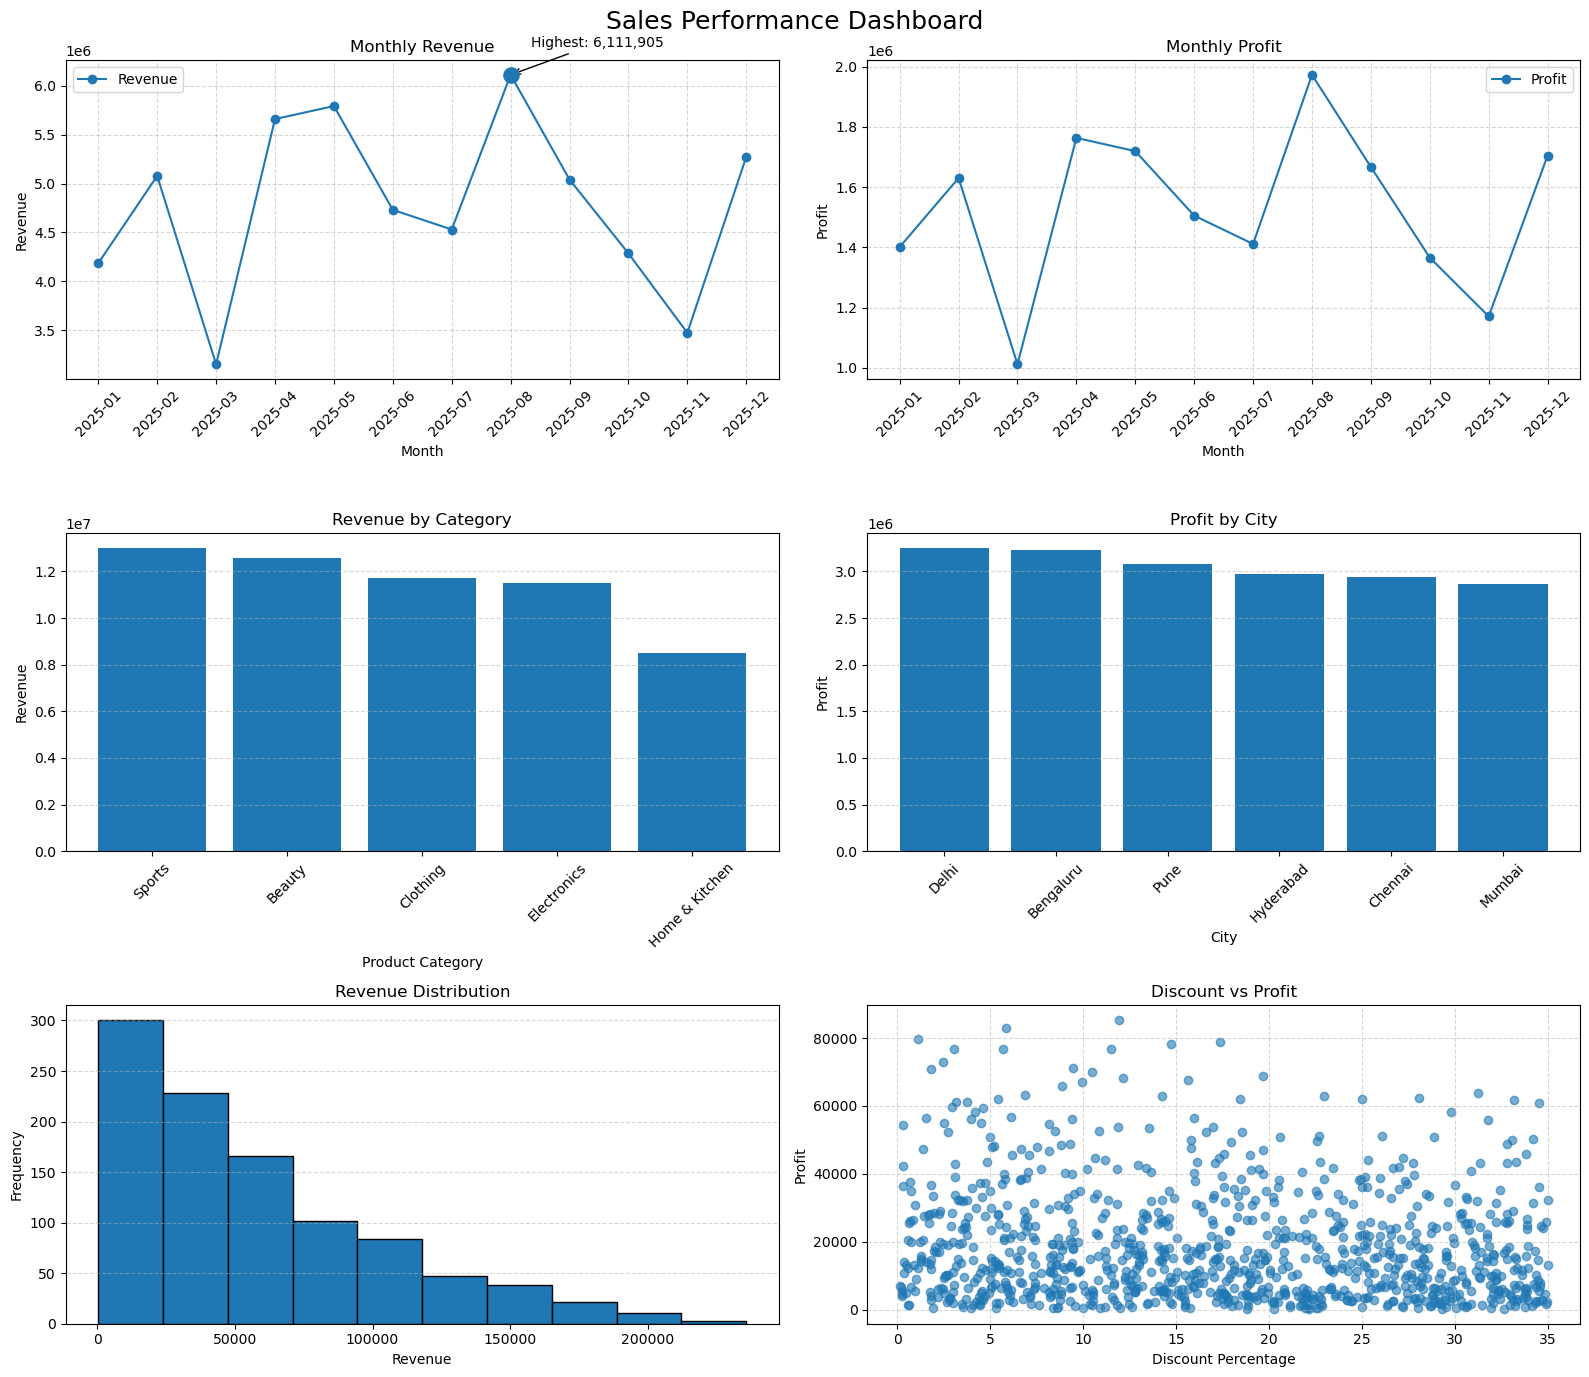

In [7]:
29.
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"],errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"],errors="coerce")
df["Discount_Pct"] = pd.to_numeric(df["Discount_Pct"],errors="coerce")

# Prepare data
monthly_revenue = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_profit = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Profit"].sum()

category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

# Find import values 
best_revenue_month=monthly_revenue.idxmax()
best_revenue=monthly_revenue.max()

# create dashboard
fig, axes = plt.subplots(3,2,figsize=(16, 14))

# 1. Monthly Revenue
axes[0, 0].plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o",
    label="Revenue"
)

best_position = list(monthly_revenue.index).index(best_revenue_month)


axes[0, 0].scatter(
    best_position,
    best_revenue,
    s=120,
    zorder=5
)

axes[0, 0].annotate(
    f"Highest: {best_revenue:,.0f}",
    xy=(best_position, best_revenue),
    xytext=(15, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True,linestyle="--",alpha=0.5)
axes[0, 0].legend()

# 2. Monthly Profit
axes[0, 1].plot(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    marker="o",
    label="Profit"
)

axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].tick_params(axis="x",rotation=45)
axes[0, 1].grid(True,linestyle="--",alpha=0.5)
axes[0, 1].legend()

# 3. Revenue by Category
axes[1, 0].bar(
    category_revenue.index,
    category_revenue.values
)

axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x",rotation=45)
axes[1, 0].grid(axis="y",linestyle="--",alpha=0.5)

# 4. Profit by City
axes[1, 1].bar(
    city_profit.index,
    city_profit.values
)

axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x",rotation=45)
axes[1, 1].grid(axis="y",linestyle="--",alpha=0.5)

# 5. Revenue Distribution
axes[2, 0].hist(
    df["Revenue"].dropna(),
    bins=10,
    edgecolor="black"
)

axes[2, 0].set_title("Revenue Distribution")
axes[2, 0].set_xlabel("Revenue")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].grid(axis="y",linestyle="--",alpha=0.5)

# 6. Discount vs Profit

axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)

axes[2, 1].set_title("Discount vs Profit")
axes[2, 1].set_xlabel("Discount Percentage")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True,linestyle="--",alpha=0.5)

fig.suptitle(
    "Sales Performance Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [1]:
30.
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")

numeric_columns = [
    "Revenue",
    "Profit",
    "Discount_Pct",
    "Customer_Age"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )
    
# Prepare analysis data 

# Monthly Revenue
monthly_revenue = (
    df.groupby(
        df["Order_Date"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

# Product Category Profit
category_profit = (
    df.groupby("Product_Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

# City Performance
city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

# Customer Segment Revenue
segment_revenue = (
    df.groupby("Customer_Segment")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

# Top 5 Profitable orders
top_5_profit = (
    df.nlargest(5, "Profit")
      .sort_values("Profit")
)

# 3. IMPORTANT FINDINGS

best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

best_category = category_profit.idxmax()
best_category_profit = category_profit.max()

best_city = city_profit.idxmax()
best_city_profit = city_profit.max()

best_segment = segment_revenue.idxmax()
best_segment_revenue = segment_revenue.max()

# 4. CREATE DASHBOARD

fig, axes = plt.subplots(3,3,figsize=(18, 15))


# 5. MONTHLY REVENUE

months = monthly_revenue.index.astype(str)

axes[0,0].plot(
    months,
    monthly_revenue.values,
    marker="o",
    linewidth=2.5,
    label="Revenue"
)

best_position = list(monthly_revenue.index).index(best_month)

axes[0,0].scatter(
    best_position,
    best_month_revenue,
    s=150,
    zorder=5
)

axes[0,0].annotate(
    f"Highest Revenue\n{best_month}\n"
    f"{best_month_revenue:,.0f}",
    xy=(best_position, best_month_revenue),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")

axes[0,0].set_title("Monthly Revenue")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")
axes[0,0].tick_params(axis="x",rotation=45)
axes[0,0].grid(True,linestyle="--",alpha=0.5)
axes[0,0].legend()


# 6. PROFIT BY PRODUCT CATEGORY
axes[0, 1].bar(
    category_profit.index,
    category_profit.values
)

best_category_position = list(category_profit.index).index(best_category)

bars[highest_category_position].set_color("red")

axes[0,1].annotate(
    f"Highest:{best_category}",
    xy=(
        best_category_position,
        best_category_profit
    ),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(arrowstyle="->")

axes[0,1].set_title("Profit by Product Category")
axes[0,1].set_xlabel("Product Category")
axes[0,1].set_ylabel("Profit")
axes[0,1].tick_params(axis="x",rotation=45)
axes[0,1].grid(axis="y",linestyle="--",alpha=0.4)

# 7. CITY PERFORMANCE

axes[1,0].bar(
    city_profit.index,
    city_profit.values
)
best_city_position = list(city_profit.index).index(best_city)

city_bars[best_city_position].set_color("red")

axes[1,0].annotate(
    f"Best City:{best_city}",
    xy=(
        best_city_position,
        best_city_profit
    ),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(arrowstyle="->")

axes[1.0].set_title("Profit by City")
axes[1.0].set_xlabel("City")
axes[1.0].set_ylabel("Profit")
axes[1.0].tick_params(axis="x",rotation=45)
axes[1.0].grid(axis="y",linestyle="--",alpha=0.4)

# 8. CUSTOMER SEGMENT REVENUE
axES[1,1].bar(
    segment_revenue.index,
    segment_revenue.values
)

best_segment_position = list(
    segment_revenue.index
).index(best_segment)

axes[1,1].annotate(
    f"Highest{best_segment}",
    xy=(
        best_segment_position,
        best_segment_revenue
    ),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

axes[1,1].set_title("Revenue by Customer Segment")
axes[1,1].set_xlabel("Customer Segment")
axes[1,1].set_ylabel("Revenue")
axes[1,1].grid(axis="y",linestyle="--",alpha=0.4)

# 9. DISCOUNT VS PROFIT

discount_data = df.dropna(
    subset=["Discount_Pct", "Profit"]
)

axes[2,0].scatter(
    discount_data["Discount_Pct"],
    discount_data["Profit"],
    alpha=0.55
)

# Trend line
if len(discount_data) > 1:
    x = discount_data["Discount_Pct"]
    y = discount_data["Profit"]

    slope, intercept = __import__("numpy").polyfit(
        x,
        y,
        1
    )

    x_line = __import__("numpy").linspace(
        x.min(),
        x.max(),
        100
    )

    y_line = slope * x_line + intercept
    

    axes[2,0].plot(
        x_line,
        y_line,
        linestyle="--",
        label="Trend"
    )

axes[2,0].set_title("Discount vs Profit")
axes[2,0].set_xlabel("Discount Percentage")
axes[2,0].set_ylabel("Profit")
axes[2,0].grid(True,linestyle="--",alpha=0.5)
axes[2,0].legend()

# 10. REVENUE DISTRIBUTION

revenue_data = df["Revenue"].dropna()

axes[2,1].hist(
    revenue_data,
    bins=10,
    edgecolor="black"
)

mean_revenue = revenue_data.mean()
median_revenue = revenue_data.median()

axes[2,1].axvline(
    mean_revenue,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_revenue:,.0f}"
)

axes[2,1].axvline(
    median_revenue,
    linestyle="-.",
    linewidth=2,
    label=f"Median = {median_revenue:,.0f}"
)

axes[2,1].set_title("Distribution of Order Revenue")
axes[2,1].set_xlabel("Revenue")
axes[2,1].set_ylabel("Frequency")
axes[2,1].grid(axis="y",linestyle="--",alpha=0.4)
axes[2,1].legend()

# 11. TOP 5 HIGHEST PROFIT ORDERS

axes[3,0].barh(
    top_5_profit["Order_ID"].astype(str),
    top_5_profit["Profit"]
)

axes[3,0].set_title("Top 5 Orders by Profit")
axes[3,0].set_xlabel("Profit")
axes[3,0].set_ylabel("Order ID")
axes[3,0].grid(axis="x",linestyle="--",alpha=0.4)

# Add profit labels
for i, values in enumerate (top_5_profit["Profit"]):
    axes[3,0].text(
        value,
        i,
        f" {value:,.0f}",
        va="center",
    )

# 12. BUSINESS SUMMARY 

axes[3,1].axis("off")

summary = (
    f"BUSINESS SUMMARY\n\n"
    f"Highest Revenue Month:\n"
    f"{best_month} ({best_month_revenue:,.0f})\n\n"
    f"Highest - Profit Category:\n"
    f"{best_category} ({best_category_profit:,.0f})\n\n"
    f"Best Performing City:\n"
    f"{best_city} ({best_city_profit:,.0f})\n\n"
    f"Top Revenue Customer Segment:\n"
    f"{best_segment} ({best_segment_revenue:,.0f})"
    f"Discount vs Profit:\n"
    f"See scatter plot and trend line\n"
    f"for the overall relationship."
)

axes[3,1].text(
    0.05,
    0.95,
    summary,
    transform=axes[3,1].transAxes,
    fontsize=12,
    verticalalignment="top"
)

# FINAL FORMATTING

fig.suptitle(
    "Business Analytics - Sales Performance Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3936041075.py, line 100)